Group #1

Harry Lazaridis, <harrylaz@kth.se>


# Summary of the results and findings

# Description of the methodology

# Numerical results

# Analysis and discussion

# Code 

## Imports

In [28]:
import numpy as np
from numpy import random
import pandas as pd
import matplotlib.pyplot as plt

## Task 1 & 2 - Discrete convolution



In [29]:
faces = np.array([4, 6, 8, 12, 20])

def p(n):
    return np.ones(n) / n

pf = p(faces[0])
for n in faces[1:]:
    pf = np.convolve(pf, p(n))

s_values = np.arange(5, 5 + len(pf))

In [30]:
table = pd.DataFrame({"s": s_values, "P(S = s)": pf})
table

,s,P(S = s)
0,5,0.000022
1,6,0.000109
2,7,0.000326
3,8,0.000760
4,9,0.001497
5,10,0.002626
6,11,0.004210
7,12,0.006293
8,13,0.008876
9,14,0.011914


In [31]:
p_low = pf[(s_values <= 10)].sum()
p_high = pf[(s_values >= 45)].sum()
p_win = p_low + p_high

print(f"P(S <= 10) = {p_low:.5f}")
print(f"P(S >= 45) = {p_high:.5f}")
print(f"P(Win) = {p_win:.5f}")

P(S <= 10) = 0.00534
P(S >= 45) = 0.00534
P(Win) = 0.01068


## Task 3, 4 & 5

In [32]:
def simulation_probability_of_win(n_trials):
    win = 0
    for _ in range(n_trials):
        S = 0 
        for n in faces:
            S += random.randint(1, n + 1) 
        if S <= 10 or S >= 45:
            win += 1
    return win / n_trials

p_win_1000 = simulation_probability_of_win(1000)

print(f"Monte Carlo simulation with 1000 trials: {p_win_1000:.5f}")
print(f"Discrete convolultion: {p_win:.5f}")


Monte Carlo simulation with 1000 trials: 0.01200
Discrete convolultion: 0.01068


In [ ]:
trials_amount = [10, 50, 100, 500, 1000, 5000, 10000, 50000, 100000]

sim = [simulation_probability_of_win(n) for n in trials_amount]

results = pd.DataFrame({
    "number_of_trials": trials_amount,
    "results": sim
})

results


,number_of_trials,results
0,10,0.00000
2,100,0.00000
3,500,0.01200
4,1000,0.01200
5,5000,0.01240
6,10000,0.01210
7,50000,0.01042
8,100000,0.01033


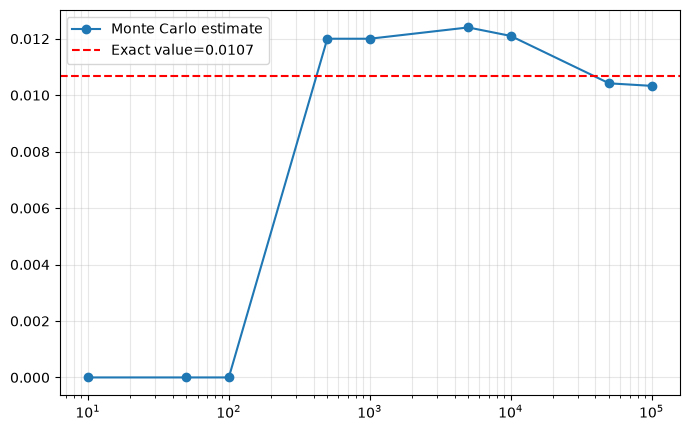

In [ ]:
plt.figure(figsize=(8, 5))
plt.semilogx(trials_amount, sim, "o-", label="Monte Carlo estimate")
plt.axhline(p_win, color="red", linestyle="--", label=f"Exact value={p_win:.4f}")
plt.xlabel("Number of trials")
plt.ylabel("Estimated P(win)")
plt.legend()
plt.grid(alpha=0.3, which="both")
plt.show()